# EDA

Цель — понять, какие признаки связаны с отменой бронирования, найти сильные зависимости и сформировать гипотезы для модели.

Важно: здесь смотрим **связи**, а не доказываем причины.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_parquet("../data/interim/hotel_bookings_clean.parquet")

print(df.shape)
df.head()


(119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,customer_type,adr,required_car_parking_spaces,total_of_special_requests,has_children,has_agent,has_company,has_agent_or_company,country_group
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,<NA>,Transient,0.0,0,0,0,0,0,0,Domestic
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,<NA>,Transient,0.0,0,0,0,0,0,0,Domestic
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,<NA>,Transient,75.0,0,0,0,0,0,0,Foreign
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,<NA>,Transient,75.0,0,0,0,1,0,1,Foreign
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,<NA>,Transient,98.0,0,1,0,1,0,1,Foreign


## 1. Target


In [2]:
target_stats = pd.DataFrame({
    "count": df["is_canceled"].value_counts(),
    "share": df["is_canceled"].value_counts(normalize=True)
})

target_stats

,count,share
is_canceled,,
0,75166,0.629584
1,44224,0.370416


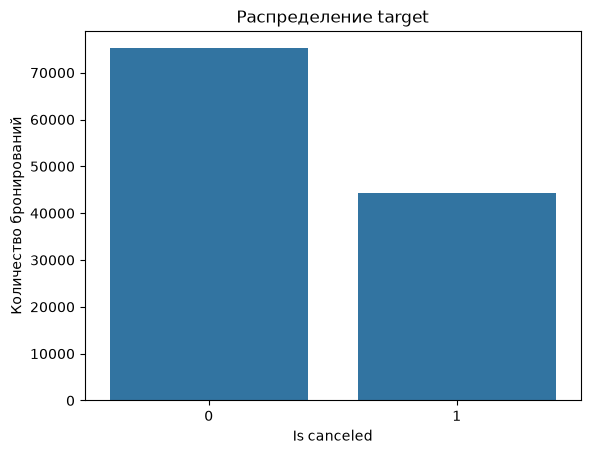

In [3]:
sns.countplot(data=df, x="is_canceled")
plt.title("Распределение target")
plt.xlabel("Is canceled")
plt.ylabel("Количество бронирований")
plt.show()

### Вывод

Около **37% броней отменяются**, 63% — нет.

Дисбаланс есть, но он не сильный. Пока ничего балансировать не буду.  
Временной split нужен отдельно — потому что данные зависят от времени, а не из-за дисбаланса классов.


## 2. Категориальные признаки vs target


Для категорий важно смотреть не только долю отмен, но и **размер группы**.  
Если в категории 2–5 объектов и cancellation rate = 100%, нормальный вывод из этого делать нельзя.


In [4]:
def cancellation_stats(col):
    return (
        df.groupby(col, observed=True)["is_canceled"]
        .agg(
            bookings="size",
            cancellations="sum",
            cancellation_rate="mean"
        )
        .sort_values("cancellation_rate", ascending=False)
    )

In [5]:
categorical_cols = [
    "hotel",
    "meal",
    "market_segment",
    "distribution_channel",
    "deposit_type",
    "customer_type",
    "reserved_room_type",
    "is_repeated_guest",
    "has_children",
    "has_agent",
    "has_company",
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(cancellation_stats(col))


--- hotel ---


,bookings,cancellations,cancellation_rate
hotel,,,
City Hotel,79330,33102,0.417270
Resort Hotel,40060,11122,0.277634



--- meal ---


,bookings,cancellations,cancellation_rate
meal,,,
FB,798,478,0.598997
BB,92310,34510,0.373849
SC,10650,3966,0.372394
HB,14463,4984,0.344603
Undefined,1169,286,0.244654



--- market_segment ---


...

,bookings,cancellations,cancellation_rate
has_children,,,
0,110058,40965,0.372213
1,9332,3259,0.349228



--- has_agent ---


,bookings,cancellations,cancellation_rate
has_agent,,,
1,103050,40194,0.390044
0,16340,4030,0.246634



--- has_company ---


,bookings,cancellations,cancellation_rate
has_company,,,
0,112593,43033,0.382200
1,6797,1191,0.175224


### Вывод

Есть несколько интересных признаков:

- `hotel`: в City Hotel отмен заметно больше, чем в Resort Hotel;
- `deposit_type`: `Non Refund` очень сильно связан с отменой;
- `has_agent`: при наличии агента доля отмен **выше**, а не ниже;
- `has_company`: при наличии компании доля отмен заметно ниже;
- у редких категорий типа `Undefined` или редких room type высокий rate может быть случайным — всегда смотрю на `bookings`.

Пока это только зависимости. Например, нельзя сказать, что агент **вызывает** отмену.


## 3. Самые интересные категориальные признаки


In [6]:
important_cat = [
    "deposit_type",
    "market_segment",
    "customer_type",
    "hotel"
]

for col in important_cat:
    print(f"\n--- {col} ---")
    display(cancellation_stats(col))


--- deposit_type ---


,bookings,cancellations,cancellation_rate
deposit_type,,,
Non Refund,14587,14494,0.993624
No Deposit,104641,29694,0.283770
Refundable,162,36,0.222222



--- market_segment ---


,bookings,cancellations,cancellation_rate
market_segment,,,
Undefined,2,2,1.000000
Groups,19811,12097,0.610620
Online TA,56477,20739,0.367211
Offline TA/TO,24219,8311,0.343160
Aviation,237,52,0.219409
Corporate,5295,992,0.187347
Direct,12606,1934,0.153419
Complementary,743,97,0.130552



--- customer_type ---


,bookings,cancellations,cancellation_rate
customer_type,,,
Transient,89613,36514,0.407463
Contract,4076,1262,0.309617
Transient-Party,25124,6389,0.254299
Group,577,59,0.102253



--- hotel ---


,bookings,cancellations,cancellation_rate
hotel,,,
City Hotel,79330,33102,0.417270
Resort Hotel,40060,11122,0.277634


### Вывод

Самый сильный результат — `deposit_type`.

У `Non Refund` cancellation rate почти 100%, причём группа большая, поэтому это уже не эффект нескольких строк.

Это выглядит очень сильным сигналом, но причина пока неизвестна. Нужно проверить, не связан ли `Non Refund` с определённым `market_segment`.


In [7]:
deposit_by_segment = (
    df.groupby(["market_segment", "deposit_type"], observed=True)["is_canceled"]
    .agg(bookings="size", cancellation_rate="mean")
    .sort_values("bookings", ascending=False)
)

deposit_by_segment

bookings  cancellation_rate
market_segment deposit_type                             
Online TA      No Deposit       56403           0.366434
Offline TA/TO  No Deposit       19209           0.172107
Direct         No Deposit       12581           0.152293
Groups         No Deposit       10509           0.282996
               Non Refund        9172           0.993240
Offline TA/TO  Non Refund        5006           0.999401
Corporate      No Deposit        4957           0.136978
Complementary  No Deposit         743           0.130552
Corporate      Non Refund         334           0.934132
Aviation       No Deposit         237           0.219409
Groups         Refundable         130           0.100000
Online TA      Non Refund          56           0.946429
Direct         Non Refund          19           0.842105
Online TA      Refundable          18           1.000000
Direct         Refundable           6           0.333333
Offline TA/TO  Refundable           4           0.500000
Corporate      Refundable           4           0.250000
Undefined      No Deposit           2           1.000000

`Non Refund` очень сильно связан с отменой бронирования. Высокий `cancellation rate` сохраняется сразу в нескольких крупных `market_segment`, поэтому зависимость нельзя объяснить только сегментом клиента. Особенно сильный эффект виден в `Groups` и `Offline TA/TO`, где выборки большие и доля отмен около 99%. Причину такой зависимости по этим данным определить нельзя, но `deposit_type` выглядит одним из самых сильных признаков для модели.


## 4. Lead time


In [8]:
df.groupby("is_canceled")["lead_time"].describe()

,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,75166.0,79.984687,91.109888,0.0,9.0,45.0,124.0,737.0
1,44224.0,144.848815,118.624829,0.0,48.0,113.0,214.0,629.0


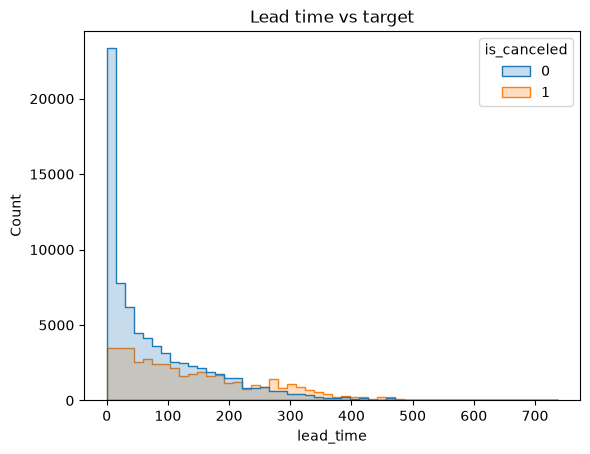

In [9]:
sns.histplot(
    data=df,
    x="lead_time",
    hue="is_canceled",
    bins=50,
    element="step"
)

plt.title("Lead time vs target")
plt.show()

In [10]:
lead_time_labels = [
    "0-7",
    "8-30",
    "31-90",
    "91-180",
    "181-365",
    "365+"
]

df["lead_time_group"] = pd.cut(
    df["lead_time"],
    bins=[-1, 7, 30, 90, 180, 365, np.inf],
    labels=lead_time_labels
)

lead_time_stats = (
    df.groupby("lead_time_group", observed=True)["is_canceled"]
    .agg(bookings="size", cancellation_rate="mean")
)

lead_time_stats

,bookings,cancellation_rate
lead_time_group,,
0-7,19746,0.096323
8-30,18960,0.278639
31-90,29553,0.376984
91-180,26439,0.447105
181-365,21544,0.554540
365+,3148,0.676620


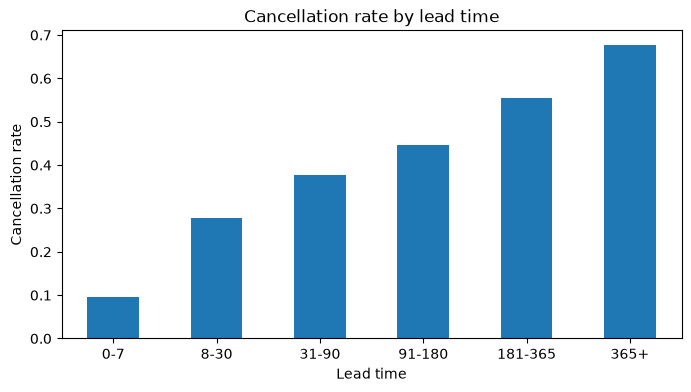

In [11]:
lead_time_stats["cancellation_rate"].plot(kind="bar", figsize=(8, 4))

plt.ylabel("Cancellation rate")
plt.xlabel("Lead time")
plt.title("Cancellation rate by lead time")
plt.xticks(rotation=0)
plt.show()

### Вывод

Очень сильная и почти монотонная зависимость:

**чем раньше относительно даты заезда человек бронирует, тем выше вероятность отмены.**

Примерно:
- 0–7 дней → около 10% отмен;
- 91–180 → около 45%;
- 365+ → около 68%.

`lead_time` выглядит одним из самых сильных признаков для будущей модели.


## 5. ADR


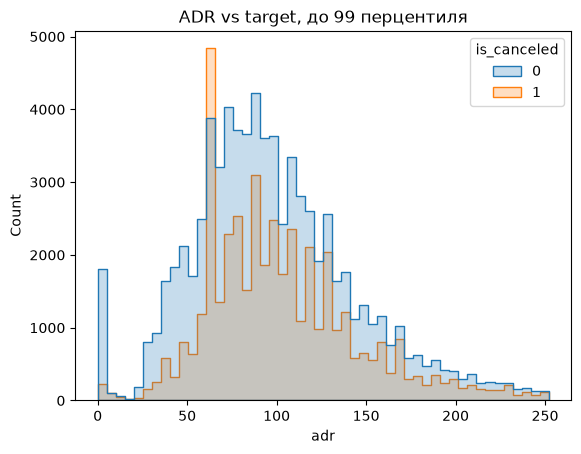

In [12]:
adr_99 = df["adr"].quantile(0.99)

sns.histplot(
    data=df[(df["adr"] >= 0) & (df["adr"] <= adr_99)],
    x="adr",
    hue="is_canceled",
    bins=50,
    element="step"
)

plt.title("ADR vs target, до 99 перцентиля")
plt.show()

In [13]:
df.groupby("is_canceled")["adr"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
is_canceled,,,
0,75166,99.987693,92.5
1,44224,104.964333,96.2


Распределение `adr` не нормальное: оно скошено вправо, есть длинный хвост и сильные выбросы.

По одной медиане сильной зависимости от target не видно, поэтому дополнительно разобью ADR на интервалы.


In [14]:
adr_for_analysis = df[
    (df["adr"] >= 0) &
    (df["adr"] <= adr_99)
].copy()

adr_for_analysis["adr_bin"] = pd.qcut(
    adr_for_analysis["adr"],
    q=10,
    duplicates="drop"
)

adr_stats = (
    adr_for_analysis
    .groupby("adr_bin", observed=True)["is_canceled"]
    .agg(bookings="size", cancellation_rate="mean")
)

adr_stats

,bookings,cancellation_rate
adr_bin,,
"(-0.001, 50.0]",11996,0.212071
"(50.0, 64.0]",11915,0.488208
"(64.0, 75.0]",13610,0.327627
"(75.0, 85.0]",10866,0.360390
"(85.0, 94.25]",10725,0.374266
"(94.25, 104.91]",11821,0.401066
"(104.91, 117.0]",12046,0.371327
"(117.0, 132.85]",11598,0.422832
"(132.85, 160.0]",11978,0.375355


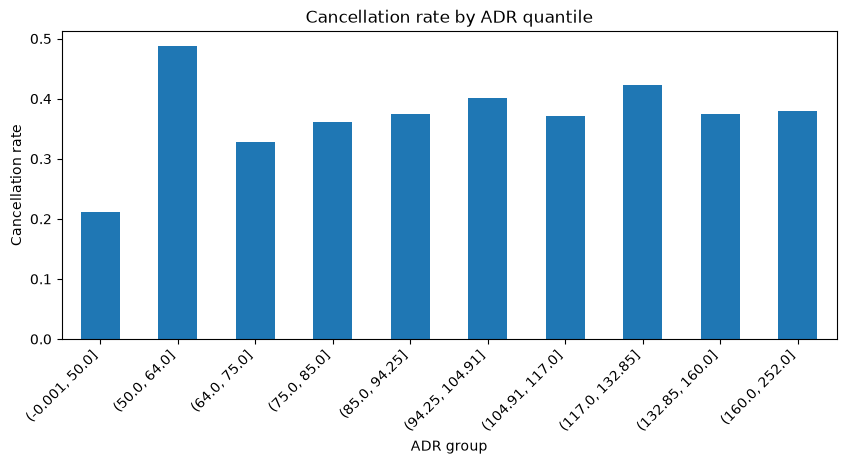

In [15]:
adr_stats["cancellation_rate"].plot(kind="bar", figsize=(10, 4))

plt.ylabel("Cancellation rate")
plt.xlabel("ADR group")
plt.title("Cancellation rate by ADR quantile")
plt.xticks(rotation=45, ha="right")
plt.show()

### Вывод

У `adr` есть выбросы, поэтому обычные средние и графики легко искажаются.

По медианам сильной разницы между отменёнными и неотменёнными бронями нет.  
Окончательный вывод делаю по группам ADR выше — если rate меняется с ценой, признак всё равно может быть полезен модели.

`ADR = 0` пока не интерпретирую как персонал/служебные брони — данных для такого вывода нет.


## 6. Время


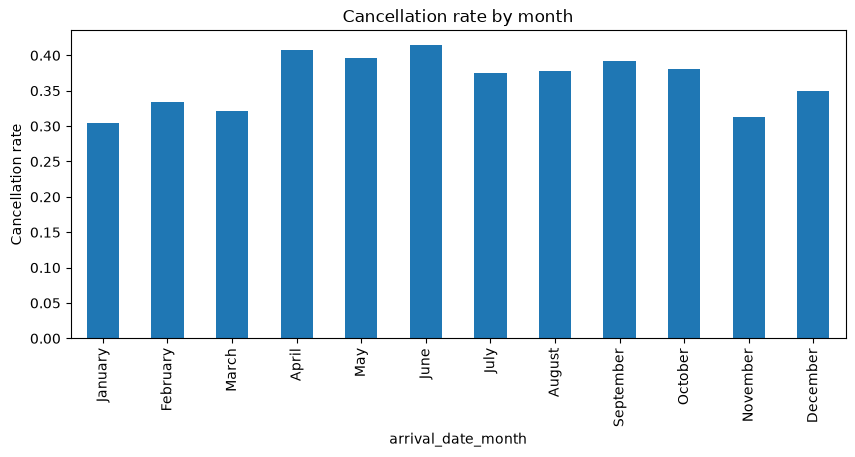

In [16]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_cancel = (
    df.groupby("arrival_date_month")["is_canceled"]
    .mean()
    .reindex(month_order)
)

monthly_cancel.plot(kind="bar", figsize=(10, 4))
plt.ylabel("Cancellation rate")
plt.title("Cancellation rate by month")
plt.show()

По месяцам разница есть, но по этому графику нельзя сразу говорить, есть сезонность или нет.

Причина: 2015 начинается летом, а 2017 заканчивается летом. Поэтому месяцы смешивают эффект месяца и эффект года.


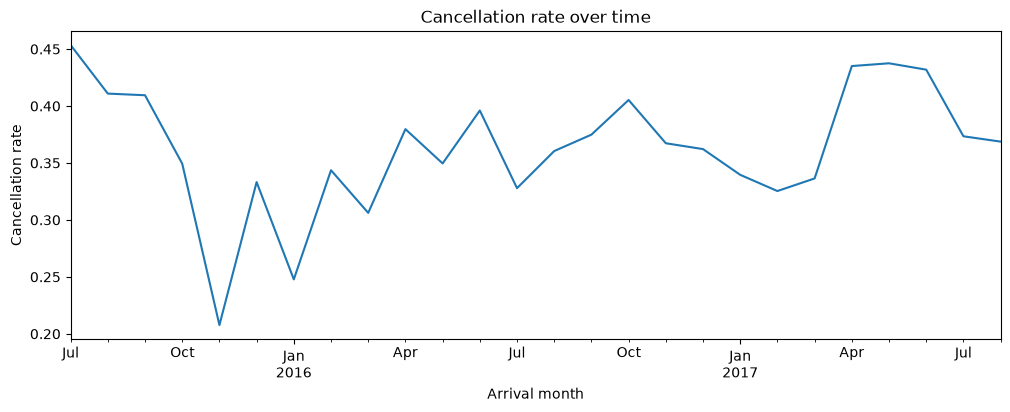

In [17]:
df["arrival_year_month"] = pd.to_datetime(
    df["arrival_date_year"].astype(str)
    + "-"
    + df["arrival_date_month"],
    format="%Y-%B"
)

monthly_timeline = (
    df.groupby("arrival_year_month")["is_canceled"]
    .mean()
    .sort_index()
)

monthly_timeline.plot(figsize=(12, 4))
plt.ylabel("Cancellation rate")
plt.xlabel("Arrival month")
plt.title("Cancellation rate over time")
plt.show()

### Вывод

Теперь можно смотреть на изменение cancellation rate во времени без смешивания годов.

Этот график также подтверждает, почему финальный train/validation/test нужно делить **по времени**, а не случайно.


## 7. Количество гостей и длительность проживания


In [18]:
df["total_guests"] = (
    df["adults"]
    + df["children"].fillna(0)
    + df["babies"]
)

df["total_nights"] = (
    df["stays_in_week_nights"]
    + df["stays_in_weekend_nights"]
)

In [19]:
guest_stats = (
    df.groupby("total_guests")["is_canceled"]
    .agg(bookings="size", cancellation_rate="mean")
    .query("bookings >= 100")
)

night_stats = (
    df.groupby("total_nights")["is_canceled"]
    .agg(bookings="size", cancellation_rate="mean")
    .query("bookings >= 100")
)

display(guest_stats)
display(night_stats)

,bookings,cancellation_rate
total_guests,,
0.0,180,0.138889
1.0,22581,0.290288
2.0,82051,0.396973
3.0,10495,0.321772
4.0,3929,0.418936
5.0,137,0.248175


,bookings,cancellation_rate
total_nights,,
0,715,0.048951
1,21020,0.250761
2,27643,0.440003
3,27076,0.419227
4,17383,0.365760
5,7784,0.342112
6,3857,0.397978
7,8655,0.343039
8,1161,0.379845


### Вывод

Сравнивать только медианы было недостаточно — одинаковая медиана ещё не означает одинаковое распределение.

Поэтому здесь смотрю cancellation rate для каждого размера группы и количества ночей, но оставляю только группы хотя бы со 100 наблюдениями.

Если явной монотонной зависимости нет — это нормально: признаки всё равно могут быть полезны в комбинации с другими.


## 8. История клиента


In [20]:
history_cols = [
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "is_repeated_guest"
]

for col in history_cols:
    print(f"\n--- {col} ---")
    display(
        df.groupby(col)["is_canceled"]
        .agg(bookings="size", cancellation_rate="mean")
    )


--- previous_cancellations ---


,bookings,cancellation_rate
previous_cancellations,,
0,112906,0.339061
1,6051,0.944307
2,116,0.327586
3,65,0.307692
4,31,0.225806
5,19,0.105263
6,22,0.318182
11,35,0.285714
13,12,0.916667



--- previous_bookings_not_canceled ---


,bookings,cancellation_rate
previous_bookings_not_canceled,,
0,115770,0.380271
1,1542,0.051232
2,580,0.055172
3,333,0.051051
4,229,0.052402
...,...,...
68,1,0.000000
69,1,0.000000
70,1,0.000000



--- is_repeated_guest ---


,bookings,cancellation_rate
is_repeated_guest,,
0,115580,0.377851
1,3810,0.144882


### Вывод

История клиента выглядит очень информативной.

- если раньше уже была хотя бы одна отмена, вероятность новой отмены сильно растёт;
- клиенты с успешными предыдущими бронированиями отменяют заметно реже;
- repeated guests отменяют гораздо реже новых клиентов.

Для больших значений `previous_cancellations` выборка маленькая, поэтому проценты 100% там нельзя воспринимать всерьёз.

Позже можно попробовать создать `has_previous_cancellation`.


## 9. Country


In [21]:
top_countries = (
    df["country"]
    .value_counts()
    .head(15)
    .index
)

country_stats = (
    df[df["country"].isin(top_countries)]
    .groupby("country")["is_canceled"]
    .agg(bookings="size", cancellation_rate="mean")
    .sort_values("cancellation_rate", ascending=False)
)

country_stats

,bookings,cancellation_rate
country,,
PRT,48590,0.566351
BRA,2224,0.373201
ITA,3766,0.353956
ESP,8568,0.254085
CHE,1730,0.247399
IRL,3375,0.246519
USA,2097,0.238913
SWE,1024,0.221680
BEL,2342,0.202391


In [22]:
df["country_group"] = np.where(
    df["country"] == "Unknown",
    "Unknown",
    np.where(
        df["country"] == "PRT",
        "Domestic",
        "Foreign"
    )
)

country_group_stats = (
    df.groupby("country_group")["is_canceled"]
    .agg(
        bookings="size",
        cancellations="sum",
        cancellation_rate="mean"
    )
    .sort_values("cancellation_rate", ascending=False)
)

country_group_stats

,bookings,cancellations,cancellation_rate
country_group,,,
Domestic,48590,27519,0.566351
Foreign,70312,16638,0.236631
Unknown,488,67,0.137295


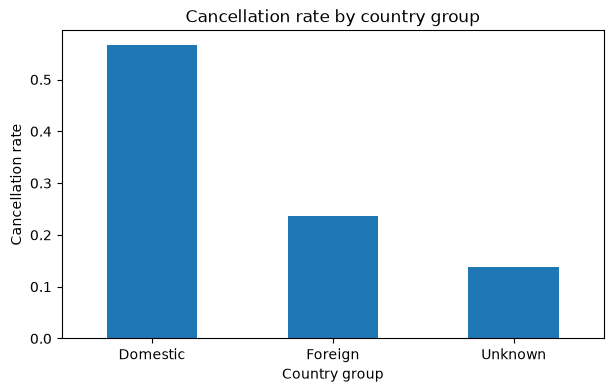

In [23]:
country_group_stats["cancellation_rate"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.ylabel("Cancellation rate")
plt.xlabel("Country group")
plt.title("Cancellation rate by country group")
plt.xticks(rotation=0)
plt.show()

### Вывод

У бронирований из `PRT` cancellation rate заметно выше, чем у иностранных клиентов.

Это сильная зависимость, но пока нельзя говорить, **почему** она возникает.  
Возможно, дело частично в типе отеля, market segment или канале бронирования.


In [24]:
country_hotel_stats = (
    df.groupby(["country_group", "hotel"], observed=True)["is_canceled"]
    .agg(bookings="size", cancellation_rate="mean")
)

country_hotel_stats

bookings  cancellation_rate
country_group hotel                                    
Domestic      City Hotel       30960           0.648611
              Resort Hotel     17630           0.421894
Foreign       City Hotel       48346           0.268874
              Resort Hotel     21966           0.165665
Unknown       City Hotel          24           0.916667
              Resort Hotel       464           0.096983

## Итог EDA

Самые интересные признаки на этом этапе:

- `lead_time` — очень сильная почти монотонная связь;
- `deposit_type` — `Non Refund` очень сильно связан с отменой;
- `previous_cancellations` — прошлые отмены дают сильный сигнал;
- `previous_bookings_not_canceled` — успешная история снижает риск;
- `is_repeated_guest` — повторные гости отменяют реже;
- `country_group` — `PRT` сильно отличается от иностранных клиентов;
- `hotel` — у City Hotel cancellation rate выше.

Что важно:

- редкие категории не оцениваю только по большому cancellation rate;
- не делаю причинные выводы из корреляций;
- выбросы пока не удаляю автоматически;
- временную структуру обязательно учту в split.

Следующий этап — **Feature Engineering + временной Train / Validation / Holdout split**.
